In [189]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import math
import os

In [190]:
# Read the data from the CSV files into pandas DataFrames

em_pd = pd.read_csv('build/output_nt_EMCal.csv', comment = '#', names= ['EventID', 'LayerID', 'Energy'])
h_pd = pd.read_csv('build/output_nt_HCal.csv', comment='#', names=['EventID', 'LayerID', 'Energy'])
track1_pd = pd.read_csv('build/output_nt_Tracker1.csv', comment = '#', names= ['EventID', 'Phi', 'Theta'])
track2_pd = pd.read_csv('build/output_nt_Tracker2.csv', comment = '#', names= ['EventID', 'Phi', 'Theta'])
truth_pd = pd.read_csv('build/output_nt_Truth.csv', comment = '#', names= ['EventID', 'Phi', 'Theta', 'Momentum', 'Particle Code'])

# Final Data from the 1000 electron-electron simulation that contained 70% classification efficiency with detected energy readings across the two magnitude range.
# Warning, running the electron-electron dataset takes ~20-30 minutes to run (event with a 100mm setcut - make sure its uncommented in build/run.mac).

# em_pd = pd.read_csv('Results/output_nt_EMCal_final.csv', comment = '#', names= ['EventID', 'LayerID', 'Energy'])
# h_pd = pd.read_csv('Results/output_nt_HCal_final.csv', comment='#', names=['EventID', 'LayerID', 'Energy'])
# track1_pd = pd.read_csv('Results/output_nt_Tracker1_final.csv', comment = '#', names= ['EventID', 'Phi', 'Theta'])
# track2_pd = pd.read_csv('Results/output_nt_Tracker2_final.csv', comment = '#', names= ['EventID', 'Phi', 'Theta'])
# truth_pd = pd.read_csv('Results/output_nt_Truth_final.csv', comment = '#', names= ['EventID', 'Phi', 'Theta', 'Momentum', 'Particle Code'])

# The muon detector data has to be treated 
muon_path = muon_pd = 'build/output_nt_MuonDetector.csv'
if os.path.exists(muon_path) and os.path.getsize(muon_path) > 0:
    muon_pd = pd.read_csv(muon_path, comment = '#', names = ['EventID', 'Phi', 'Theta'])
else:
    muon_pd = pd.DataFrame(columns = ['EventID', 'Phi', 'Theta']) # empty placeholders

# Map the particle codes to their corresponding particle types - proton as 3 and neutron as 4. They are disregarded in them in the classification
# as they aren't created in the simulation, except for some neutrons but they are secondary particles created in the hadronic showers and are not recorded
code_map = {0: 'electron', 1: 'muon', 2: 'photon', 3: 'hadron', 4: 'hadron', 99: 'other'}

# Saves Total energy per event 
em_total = em_pd.groupby('EventID')['Energy'].sum()
h_total = h_pd.groupby('EventID')['Energy'].sum()

# Saves per layer shower profiles

em_layers = em_pd.pivot_table(index = 'EventID', columns = 'LayerID', values = 'Energy', fill_value = 0)
h_layers = h_pd.pivot_table(index = 'EventID', columns = 'LayerID', values = 'Energy', fill_value = 0)

# Create a new column in the truth DataFrame to store the particle types
truth_pd['TrueType'] = truth_pd['Particle Code'].map(code_map)

dataset = {'ee'} # Current dataset - change when needed (used to distinguish saved figures)

# 1. Classification

In [191]:
# Combine information from all detectors to classify particles and compare with truth information

# Get unique event IDs from all detectors - this method was dropped as it didn't account for particles that didn't deposit any energy: 'unclassified'
# all_event_ids = sorted(set(em_pd['EventID']) | set(h_pd['EventID']) | set(muon_pd['EventID']))


all_event_ids = sorted(truth_pd['EventID'].unique())
# Get unique event IDs from tracker hits
events_with_tracker_hits = set(track1_pd['EventID'].unique())
events_with_tracker2_hits = set(track2_pd['EventID'].unique())

# Give unique tracks per event
# track2_counts = track2_pd.groupby('EventID').size().to_dict()

results = []

# Loop through each event and classify the particle based on detector hits and energy deposits
for event_id in all_event_ids:
    # Get hits for the current event from each detector
    em_hits = em_pd[em_pd['EventID'] == event_id]
    h_hits = h_pd[h_pd['EventID'] == event_id]
    muon_hits = muon_pd[muon_pd['EventID'] == event_id]

    # Calculate total energy deposits in EM and H calorimeters
    em_energy = em_hits['Energy'].sum()
    h_energy = h_hits['Energy'].sum()
    total_energy = em_energy + h_energy

    # Calculate the fraction of energy deposited in the EM calorimeter - useful for distinguishing between electrons and hadrons
    em_frac = em_energy / total_energy if total_energy > 0 else 0

    # Determine if there are hits in the muon detector and tracker
    muon_hit = len(muon_hits) > 0
    tracker_hit = event_id in events_with_tracker_hits
    tracker_hit2 = event_id in events_with_tracker2_hits

    # This was an attempt distinguish between electrons and photons. Where photons who decayed to e-e+ pairs immediately after production would have a track in tracker 2
    # from the e-e+ pair curving in the EM calorimeter back into tracker 2. This was not a very effective method and led to more problems then fixes. 
    # 1 track = electron, 2 tracks = photon pair production
    # n_tracks = track2_counts.get(event_id, 0)
    

    # Get true particle information for the current event
    true_particle = truth_pd[truth_pd['EventID'] == event_id]
    true_momentum = true_particle['Momentum'].iloc[0] if len(true_particle) > 0 else np.nan

    # Classify the particle based on the detector information

    if muon_hit: # real muon needs significant HCal deposit too
        particle_type = 'muon'
    elif total_energy == 0 and not tracker_hit:
        particle_type = 'unclassified'
    elif total_energy == 0 and tracker_hit:
        particle_type = 'unclassified'
    elif not tracker_hit2 and em_frac > 0.95 : # Tracker 2 here to reduce situations where photon decays immediately to e-e+
        particle_type = 'photon' # EM shower but no track
    elif tracker_hit2 and em_frac > 0.95:
        particle_type = 'electron' # EM shower with track
    elif tracker_hit and em_frac < 0.5:
        particle_type = 'hadron'
    else:
        particle_type = 'unclassified'

    # Append the results for the current event to the results list
    results.append({
        'EventID': event_id,
        'EM_Energy': em_energy,
        'H_Energy': h_energy,
        'Total_Energy': total_energy,
        'Muon_Hit': muon_hit,
        'Tracker_Hit': tracker_hit,
        'RecoType': particle_type,
        'True_Momentum': true_momentum
    })

results_df = pd.DataFrame(results)
results_df 

,EventID,EM_Energy,H_Energy,Total_Energy,Muon_Hit,Tracker_Hit,RecoType,True_Momentum
0,0,0.000000,0.000000,0.000000,True,True,muon,45.202400
1,1,0.490901,0.862035,1.352936,True,True,muon,45.499900
2,2,0.289299,0.873041,1.162341,True,True,muon,45.499900
3,3,0.342602,0.896755,1.239357,True,True,muon,45.495800
4,4,0.327991,0.692130,1.020122,True,True,muon,45.486200
5,5,0.234001,0.719077,0.953078,True,True,muon,45.499900
6,6,0.580298,0.666750,1.247047,True,True,muon,0.161674
7,7,0.000000,0.000000,0.000000,True,False,muon,45.499900
8,8,0.000000,0.000000,0.000000,True,False,muon,45.499900
9,9,0.000000,0.000000,0.000000,True,False,muon,0.231598


In [192]:
# Here we calculate the classification efficiency by comparing the reconstructed particle type to the true particle type 

# Sets a new column in results_df to store the true particle type for each event
results_df['TrueType'] = None

# Iterates over each row in results_df to find the corresponding true particle type from truth_pd based on the EventID
for idx, row in results_df.iterrows():
    event_truth = truth_pd[truth_pd['EventID'] == row['EventID']]
    if len(event_truth) == 0:
        continue

    # First tries to find a muon hit for the event, if found uses its Phi as reference
    muon_hit = muon_pd[muon_pd['EventID'] == row['EventID']]

    # If a muon hit is found, we use its Phi as the reference for matching
    if len(muon_hit) > 0:
        ref_phi = muon_hit['Phi'].iloc[0]

    # If no muon hit is found but there are tracker hits, we use the Phi from the first tracker hit as reference
    elif row['EventID'] in events_with_tracker_hits:
        tr_hits = track1_pd[track1_pd['EventID'] == row['EventID']]
        ref_phi = tr_hits['Phi'].iloc[0] if len(tr_hits) > 0 else 0

    else:
        ref_phi = 0

    # Calculates the absolute difference in Phi between the true particles and the reference Phi, and finds the closest match
    phi_diff = np.abs(event_truth['Phi'] - ref_phi)
    # Finds the index of the true particle with the smallest Phi difference and assigns its TrueType to the results_df
    closest_truth = event_truth.loc[phi_diff.idxmin()]
    # Assigns the TrueType of the closest matching true particle to the results_df for the current event
    results_df.at[idx, 'TrueType'] = closest_truth['TrueType']

# Now we can calculate the classification efficiency by comparing the RecoType to the TrueType for each event
results_df['Correct'] = results_df['RecoType'] == results_df['TrueType']
overall_efficiency = results_df['Correct'].sum() / len(results_df)
print(f"Overall Efficiency: {overall_efficiency:.4f}")

# Make a breakdown of efficiency by particle type
for particle in ['electron', 'muon', 'photon', 'hadron', 'unclassified']:
    subset = results_df[results_df['TrueType'] == particle]
    if len(subset) > 0:
        eff = subset['Correct'].sum() / len(subset)
        print(f"{particle.capitalize()} Efficiency: {eff:.4f}")

Overall Efficiency: 1.0000
Muon Efficiency: 1.0000


I had a lot of trouble with getting the classification correct, which can be attributed to the very late realization that only the last layers of both calorimeters were actually sensitive.
I was stuck with efficiencies at 0.0 - 0.1 for the electron dataset and 0.5 - 0.6 for the muon dataset (only coming from muons).
Changes:

Had to make edits to DetectorConstruction.cpp/.h to change the LogicalVolume to a vector that would appropriately classify each lAr and scintillator layer as sensitive:
- Electron efficiency: 0.0 -> ~0.6 (ee)

Changed the muon detector to accept only muons instead of the all charged particles:
- Electron efficiency: 0.0 -> ~0.7 (ee)

Added endcaps (with a realistic aperture) to detect muons that have higher pseudorapidity. In addition, I increased the thickness of both the endcaps and the muon detector to increase muon hit counts:
- Muon efficiency: 0.6 -> ~1.0 (mumu)

An issue that still persists is the photon efficiency, as photons produced as primary particles undergo quick decay to electron-positron pairs that hit the trackers and lead to misclassifications. To mediate this, we used tracker2 hits as a checkpoint check for the electrons and photons, so that the photons would have to survive til tracker 2 to not leave any hit. There are still some issues where the photon will decay immediately into e-e+ that spiral back into tracker 2 since they are adjacent to each other. This still reduced the errors in misclassification:
- Electron efficiency: 0.0 -> ~0.8 (ee)
- Photon efficiency: 0.0 -> ~0.15 (ee)

One way to fix the classifications of the photons and electrons would be to compare shower depths. Photons and electrons differ in decay interactions, so their showers look different and can be used to distinguish between the two. After looking at the simulations and comparing the shower profiles, it seems as though the electrons and photons share similar amounts of deposited energy per layer. 

One other push I had to see if the efficiency and other results improved was to switch the calorimeter material from Pb/Fe to Uranium 238 with its higher density ($\rho$ = 18.95 g/cm^3) and smaller radiation length ($\chi_0$ = 0.32 cm) compared to Pb ($\rho$ = 11.35 g/cm^3 and $\chi_0$ = 0.56 cm) and Fe ($\rho$ = 7.87 g/cm^3) and ($\chi_0$ = 1.76 cm). In doing so, we got:

- Muon efficiency: 1.0 (mumu)
- Photon efficiency: 0.0 (mumu)
- Electron efficiency: 0.76 (ee)
- Photon efficiency: 0.05-0.15 (ee)

This was interesting, with similar results as recorded before. I believe this is due to the fact that the thickness of the layers is much larger than the radiation lengths in both Pb and Ur, so instead, we'll look into changing the thickness of the layers. Changing the ratio of the non-sensitive and sensitive layers (described in more detail in section 4) did slightly decreased the classification rates for electrons and photons:
- Electron efficiency: 0.75-0.80 (ee)
- Photon efficiency: 0.05-0.10 (ee)
- Muon efficiency: 0.95- 1.0 (mumu)
- Photon efficiency: 0.0 (mumu)
- Overall ~ 0.7 (ee), ~0.97 (mumu)

The final run I ran for (ee) dataset with a < 20 GeV detection had a classification efficiency of:
- Overall Efficiency: 0.7030
- Electron Efficiency: 0.7928
- Photon Efficiency: 0.1324

Thus, hitting both suggested marks for a single event run, the plots for this run are all tagged (final) in the filenames. The detector settings were left unchanged after this run, with the csv outputs saved with a (final) tag on them, and can be run in the first cell.

For better classification, instead of using a bunch of if statements, a DNN can be created to train on the output files of the trackers and calorimeters and validated with the truth output. This could obtain much better results, but due to the time constraint of this project, it was sidelined in favor of trying other Geant4 detector tinkering methods, as I liked using the program and also wanted to improve my C++.

In [193]:
results_df

,EventID,EM_Energy,H_Energy,Total_Energy,Muon_Hit,Tracker_Hit,RecoType,True_Momentum,TrueType,Correct
0,0,0.000000,0.000000,0.000000,True,True,muon,45.202400,muon,True
1,1,0.490901,0.862035,1.352936,True,True,muon,45.499900,muon,True
2,2,0.289299,0.873041,1.162341,True,True,muon,45.499900,muon,True
3,3,0.342602,0.896755,1.239357,True,True,muon,45.495800,muon,True
4,4,0.327991,0.692130,1.020122,True,True,muon,45.486200,muon,True
5,5,0.234001,0.719077,0.953078,True,True,muon,45.499900,muon,True
6,6,0.580298,0.666750,1.247047,True,True,muon,0.161674,muon,True
7,7,0.000000,0.000000,0.000000,True,False,muon,45.499900,muon,True
8,8,0.000000,0.000000,0.000000,True,False,muon,45.499900,muon,True
9,9,0.000000,0.000000,0.000000,True,False,muon,0.231598,muon,True


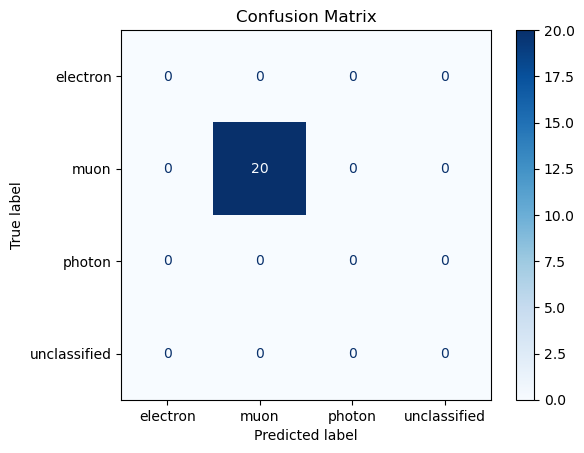

In [194]:
# Plotting the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create a confusion matrix
cm = confusion_matrix(results_df['TrueType'], results_df['RecoType'], labels=['electron', 'muon', 'photon', 'unclassified'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['electron', 'muon', 'photon', 'unclassified'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

The confusion matrix shows classification performance for the current run. In the (mumu) dataset, muon tags are correctly identified at an approximate 100% rate, distinguished clearly by hits with the muon detector system.

 In the (ee) dataset, the primary source of misclassifications are:

 - Photons tagged as electrons: photons decaying to e+e- pairs sometimes bounce back into the center of the detector from the em calorimeter and trigger the tracker hits. This could be minimized by somehow disabling multiple sequential tracker2 hits from particles in the same eventID.
- Unclassified electrons/photons: high-pseudorapidity secondaries from Bremsstrahlung escape along the beam axis without triggering the tracker, so they accumulate no hits and fall into the unclassified bin.
 
The final (ee) run achieved an overall; efficiency of 70.3% with electron efficiency of 79.3% and photon efficiency of 13.2%, meeting the project 70% target.

# 2. Momentum Resolution

In [195]:
# Calculate the momentum of charged particles using the sagitta method based on hits in the two tracker layers

layer1Rad = 4.0 # m
L = 8.0 # m
B = 0.5 # T

# Find pairs of hits in the two tracker layers that correspond to the same particle based on their EventID and Theta values
pairs = []

# Loop through each unique event ID and find pairs of hits in the two tracker layers that have similar Theta values
for event_id in all_event_ids:
    hits1 = track1_pd[track1_pd['EventID'] == event_id]
    hits2 = track2_pd[track2_pd['EventID'] == event_id]

    for _, hit1 in hits1.iterrows():
        for _, hit2 in hits2.iterrows():
            if math.fabs(hit1['Theta'] - hit2['Theta']) < 0.01:
                pairs.append({
                    'EventID': event_id,
                    'Phi1': hit1['Phi'],
                    'Phi2': hit2['Phi'],
                    'Theta': hit1['Theta']
                })
                break

pairs_df = pd.DataFrame(pairs)

# Calculate the sagitta and momentum for each pair of hits in the two tracker layers
pairs_df['∆Phi'] = np.abs(pairs_df['Phi2'] - pairs_df['Phi1'])
pairs_df['Sagitta'] = np.sin(pairs_df['∆Phi']) * layer1Rad
pairs_df['R'] = (L**2)/ (8  * pairs_df['Sagitta'])
pairs_df['Pt'] = 0.3 * B * pairs_df['R']
pairs_df['Mom.'] = pairs_df['Pt'] / np.sin(pairs_df['Theta'])
pairs_df

,EventID,Phi1,Phi2,Theta,∆Phi,Sagitta,R,Pt,Mom.
0,1,-2.447600,-2.455780,0.928389,0.008180,0.032720,244.501504,36.675226,45.806483
1,1,0.710400,0.718654,2.213210,0.008254,0.033016,242.309512,36.346427,45.396036
2,2,-1.703800,-1.712050,2.212230,0.008250,0.033000,242.426992,36.364049,45.384786
3,2,1.454280,1.462530,0.929343,0.008250,0.033000,242.426992,36.364049,45.385452
4,3,0.335396,0.327373,2.182470,0.008023,0.032092,249.285985,37.392898,45.674169
5,3,-2.790060,-2.782040,0.959133,0.008020,0.032080,249.379232,37.406885,45.690922
6,4,0.710502,0.703090,2.043770,0.007412,0.029648,269.835174,40.475276,45.466721
7,4,-2.416400,-2.408960,1.098020,0.007440,0.029760,268.819684,40.322953,45.291040
8,4,-2.416460,-2.408960,1.098010,0.007500,0.030000,266.669167,40.000375,44.928949
9,4,-2.412990,-2.408960,1.100350,0.004030,0.016120,496.279259,74.441889,83.514385


The muon resolution is calculated using the sagitta method highlighted in the previous workshop: two tracker layers separated by 4 meters in a 0.5 T solenoidal field allows the transverse momentum to be estimated from the deflection angle between hits.

The calculation of the momentum stems from the Sagitta (the deviation of a track from a straight trajectory due to the magnetic field):

$ s = \sin(\Delta \Phi) * r_{1}$;
$\Delta \Phi$ is the change in radial and $r_{1}$ is the radius of the first tracking layer

Then to get the bending radius of the track we use:

$ R = L^2/ 8s$;
$ L $ is the total path length (8 meters)

We then find the tranverse momentum using:

$p_T = 0.3 * B * R$;
with $B$ as the magnetic field strenght in tesla

Finally we obtain the total momentum with:

$ p = p_T / \sin(\theta)$;
with $\theta$ being the angle of the particles to the z-axis (beam axis)

This momentum is our reconstructed momentum, and is tested with the true momentums to find the resolution of our tracking system: $ (p_{reco} - p_{true})/p_{true} $. This is obtained below and plotted for the simulation.

*Note: This could be improved using multiple tracking layers to improve the tracking curve calculation rather than assuming the tracks are almost straight.

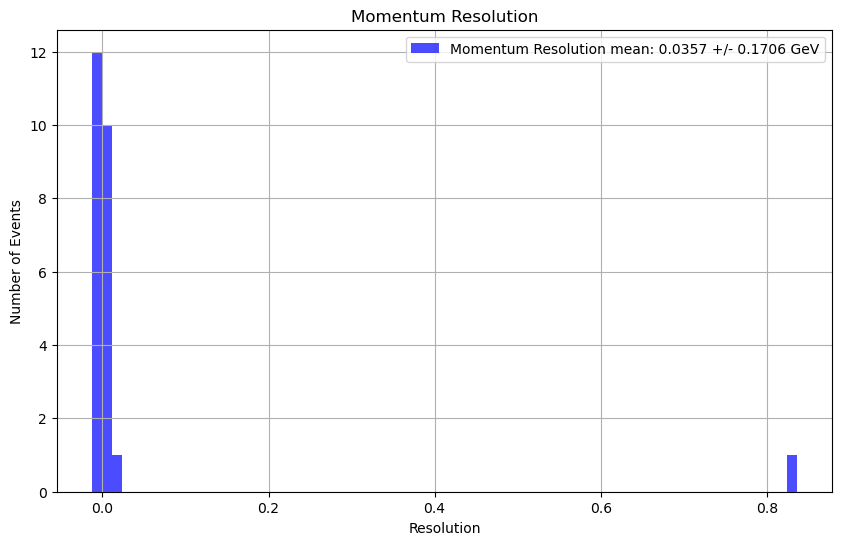

Momentum Resolution mean: 0.0357 +/- 0.1706.


In [196]:
# Compare the reconstructed momentum with the true momentum from the truth information and calculate the resolution
resolution = []
p_true_vals = []

# Iterate over each pair of hits in the two tracker layers
for _, pair in pairs_df.iterrows():
    # Find the true particle corresponding to the current pair of hits based on the EventID and Theta values
    true_paritcles = truth_pd[truth_pd['EventID'] == pair['EventID']]
    theta_diff = np.abs(true_paritcles['Theta'] - pair['Theta'])

    
    # Find the index of the true particle with the smallest Theta difference and get its information
    closest = true_paritcles.loc[theta_diff.idxmin()]

    # Finds the momentum of the closest true particle and calculates the resolution as (p_reco - p_true) / p_true
    p_true = closest['Momentum']
    p_reco = pair['Mom.']
    resolution.append((p_reco - p_true) / p_true)
    p_true_vals.append(p_true)


pairs_df['Resolution'] = resolution 
pairs_df['p_true'] = p_true_vals # store for filtering out outliers which were few but contained extremely high momentum values that skewed the resolution distribution

# Filtering both reco and true mom.
# Adding the pairs_df['p_true'] > 0.5 changed results from 485.2779 +/- 8572.9285 to -0.0102 +/- 1.7885 for ee dataset. 

reasonable = (pairs_df['Mom.'] > 0.5) & (pairs_df['Mom.'] < 100) & (pairs_df['p_true'] > 0.5)
pairs_clean = pairs_df[reasonable]

plt.figure(figsize=(10, 6))
plt.hist(pairs_clean['Resolution'], bins=70, alpha=0.7, color='blue', label = f'Momentum Resolution mean: {pairs_clean['Resolution'].mean():.4f} +/- {pairs_clean['Resolution'].std():.4f} GeV')
plt.title('Momentum Resolution')
plt.xlabel('Resolution')
plt.ylabel('Number of Events')
plt.legend()
plt.grid()
#plt.savefig(f'Results/Momentum Resolution: {dataset} (final).png', dpi = 150, bbox_inches='tight')
plt.show()

print(f"Momentum Resolution mean: {pairs_clean['Resolution'].mean():.4f} +/- {pairs_clean['Resolution'].std():.4f}.")

The momentum resolution for the (mumu) set is close to zero (slight underestimate) means there's a little systemic bias. For the (ee) set is broader due to the presence of secondary charged particles and harder-to-pair hits. Events with reconstructed or true momentum below 0.5 GeV are excluded to remove low-energy secondaries that produce extreme sagitta values.

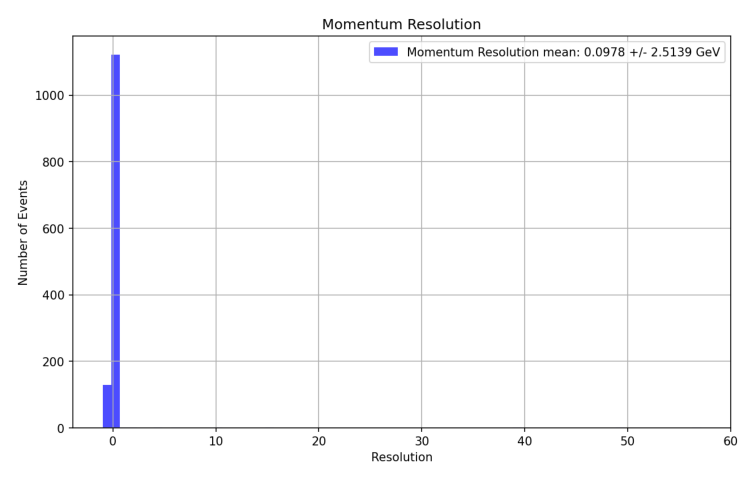

In [197]:
# Final Momentum Resolution Plot: (taken from "Results/Momentum Resolution: ee (final).png")

img = mpimg.imread("Results/Momentum Resolution: {'ee'} (final).png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

# 3. Energy Resolution

The cell below is the old method used to calculate the energy resolution; it incorrectly compares the Total_Energy (taken from both particles produced in an event) to the True_Momentum (containing only one particle's true momentum). This leads to mismatched resolutions with double-counting bias that was only identified after saving all the plots and experimental runs seen in the Results folder. An updated version has the (final) tag in the filename and uses the method in the second cell.

In [198]:
# # Records only events with energy deposits in the calorimeters
# has_deposit = results_df['Total_Energy'] > 0

# # Add minimum momentum to cut out contributions from near zero secondary particles:
# reasonable_momentum = results_df['True_Momentum'] > 1.0 # GeV

# # Calculate the mean true momentum and mean detected energy for events with deposits and reasonable momentum
# E_true_mean = results_df.loc[has_deposit & reasonable_momentum, 'True_Momentum'].mean()
# E_detected_mean = results_df.loc[has_deposit & reasonable_momentum, 'Total_Energy'].mean()   

# # Calculate the calibration factor as the ratio of the mean true momentum to the mean detected energy
# cali_factor = E_true_mean / E_detected_mean

# print(f"Calibration factor: {cali_factor:.4f}")

# results_df['Calibrated_Energy'] = results_df['Total_Energy'] * cali_factor
# reco_only = results_df[has_deposit & reasonable_momentum].copy()
# reco_only['Resolution'] = (reco_only['Calibrated_Energy'] - reco_only['True_Momentum']) / reco_only['True_Momentum']
# reco_only

Correct Analysis based off incorrect method of calculation:

For the (ee) dataset, after a while, an 18.1855 calibration factor was achieved, meaning our detector captures about 5% of the true energy. However, we have lots of low-energy secondaries that influence the plot with a positive tail as their E_true is ~0 (this decreased to ~13 after increasing active layer size and the number of layers). For the mumu dataset, the 51.2542 value is misleading n since muons aren't meant to be detected in calorimeters due as they're minimum ionizing particles. For that dataset, the momentum resolution has much more value. 

After reworking the layer thicknesses, the final calibration factor was decreased to a new low of 2.9737. This makes sense as the focus of reworking the layer thicknesses was to detect more energy deposits in each layer. Thus, higher energy readings mean that there is less calibration to the true energy for each event.

The energy resolution uses the total energy obtained from event and comparing it to the true momentum. This is used to obtain a calibration factor for our detector, set as $E_{true} / E_{detected}$ (where $E_{true} = p_{true}$) averaged over all events. And then build the resolution in the same manner as the momentum with $(E_{calibrated} - E_{true})/E_{true}$. 

<function matplotlib.pyplot.show(close=None, block=None)>

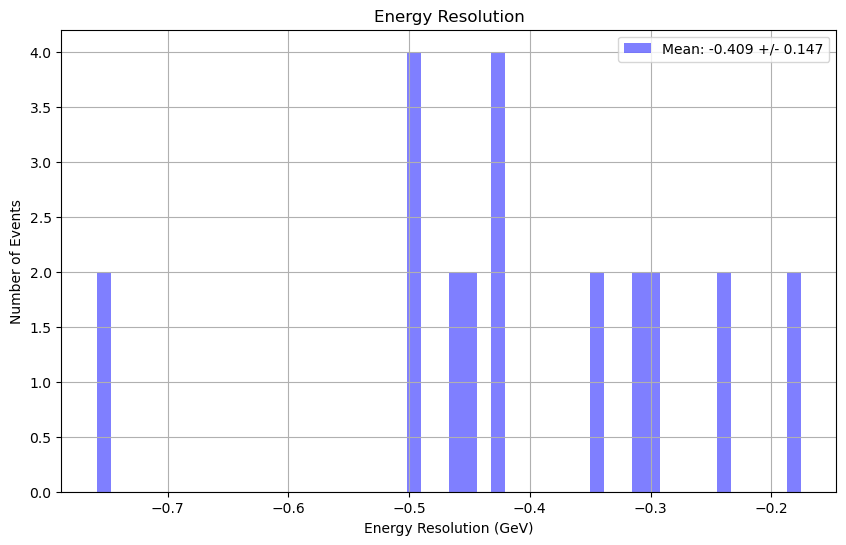

In [199]:
# Now use the correct pairing technique to calculate energy resolution

per_particle_rows = []

# Obtain the calibration factor to apply to the detected energy to get a accurate estimate of the true energy for energy resolution calculation
for _, row in results_df.iterrows():
    if row['Total_Energy'] > 0 and row['True_Momentum'] > 1.0: # Filters events with energy deposits and reasonable true momentum
        per_particle_rows.append({
            'EventID': row['EventID'],
            'True_Momentum': row['True_Momentum'],
            'Total_Energy': row['Total_Energy']
        })

pp_df = pd.DataFrame(per_particle_rows)
cali_factor = pp_df['True_Momentum'].mean() / pp_df['Total_Energy'].mean()

energy_resolution = []

# Iterate over each pair of hits in the two tracker layers and find the corresponding true particle to calculate the energy resolution
# Same method from momentum resolution
for _, pair in pairs_df.iterrows():
    event_id = pair['EventID']

    true_particles = truth_pd[truth_pd['EventID'] == event_id]
    theta_diff = np.abs(true_particles['Theta'] - pair['Theta'])
    closest = true_particles.loc[theta_diff.idxmin()]
    p_true = closest['Momentum']

    if p_true < 1.0: # filters low energy secondary particles
        continue

    # Now get calorimeter energy for the events
    event_em = em_pd[em_pd['EventID'] == event_id]['Energy'].sum()
    event_h = h_pd[h_pd['EventID'] == event_id]['Energy'].sum()
    e_detected = (event_em + event_h)/2  # This gives us a correct detected energy from one particle

    e_cali = e_detected * cali_factor # Apply the calibration factor to get a better estimate of the true energy

    energy_resolution.append({
        'EventID': event_id,
        'E_true': p_true,
        'E_cal': e_cali,
        'Resolution': (e_cali - p_true)/p_true
    })

e_res_df = pd.DataFrame(energy_resolution)

plt.figure(figsize = (10,6))
plt.hist(e_res_df['Resolution'], bins = 50, alpha = 0.5, color = 'blue', label = f'Mean: {e_res_df['Resolution'].mean():.3f} +/- {e_res_df['Resolution'].std():.3f}')
plt.xlabel('Energy Resolution (GeV)')
plt.ylabel('Number of Events')
plt.title(f'Energy Resolution')
plt.legend()
plt.grid()
#plt.savefig(f'Results/Energy Resolution {dataset} (final).png', dpi = 150, bbox_inches='tight')
plt.show

The energy resolution is computed by matching each reconstructed track's true momentum (from truth output) to the calorimeter energy deposit in that event. A calibration factor is calculated using the mean ratio of the two across all events.

The mean resolution stays consistently below |0.5| (lower for (ee) dataset ~ |0.2|). This is expected for the calorimeter set up as a lot of the shower energy is absorbed in the non-sensitive layers (Pb/Fe) rather then the sensitive (lAr/scintillator) layers. And the calibration doesn't fully express this. We still see some outliers which are highlighted in the standard deviation.

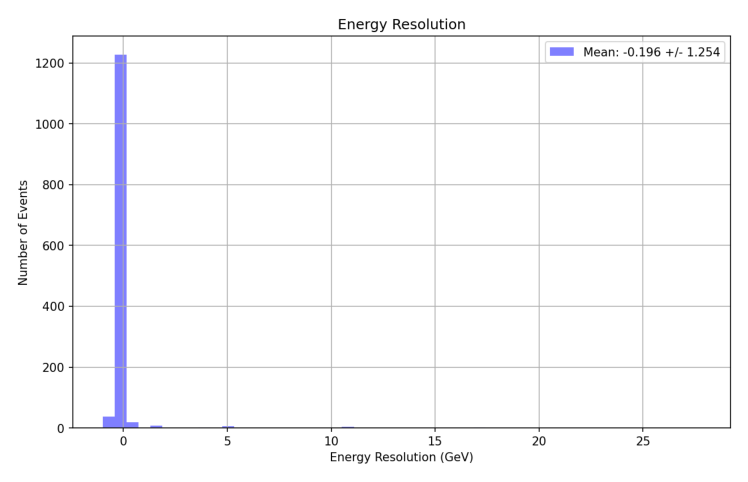

In [200]:
# Final Energy Resolution Plot: (taken from "Results/Energy Resolution {'ee'} (final).png")

img = mpimg.imread("Results/Energy Resolution {'ee'} (final).png")
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

# 4. Energy Distribution

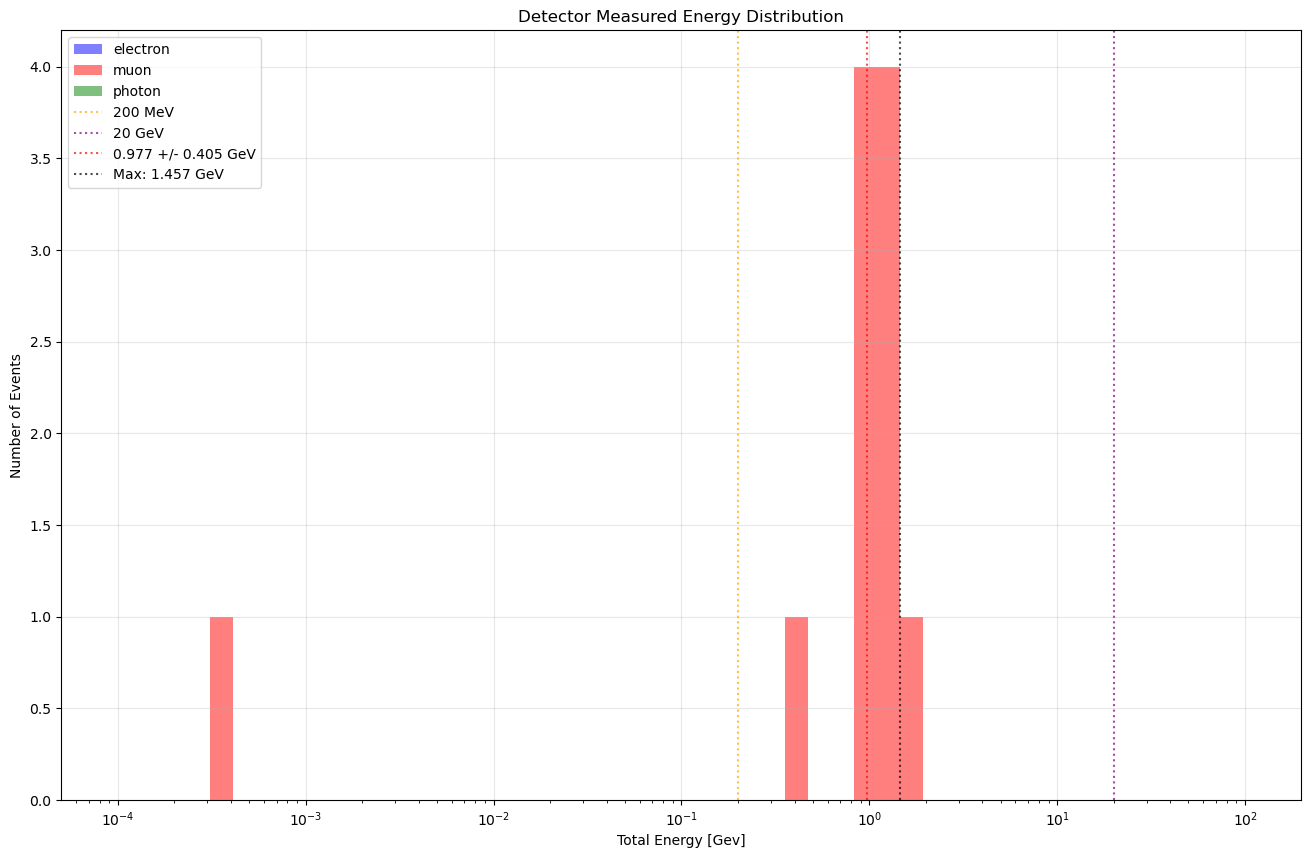

In [201]:
# Plot of the Energy Distribution 
colors = {'electron': 'blue', 'muon': 'red', 'photon': 'green'}
bins = np.logspace(-4, 2, 50) # Log - spaced bins from 10^-4 to 10^2 - reduced the clutter from 10^-4 to 10^0

plt.figure(figsize=(16,10))
for ptype, color in colors.items():
    subset = results_df[(results_df['TrueType'] == ptype) & # Labels use true particle types to avoid bias from misclassification (focus of this plot was the detected energy)
                        (results_df['Total_Energy'] > 0)]
    plt.hist(subset['Total_Energy'], bins = bins, alpha = 0.5, color = color, label = ptype)

# Incorrect subset statistics - only took last subset (photons):

# mean = np.mean(subset['Total_Energy'])
# std = np.std(subset['Total_Energy'])
# max = np.max(subset['Total_Energy']) 

# Now uses all detected events to calculate mean, std, and max:

all_detected = results_df[results_df['Total_Energy'] > 0]['Total_Energy']

mean = np.mean(all_detected)
std = np.std(all_detected)
max_val = np.max(all_detected)

plt.axvline(x= 0.2, color = 'orange', linestyle = ':', linewidth = 1.5, label = '200 MeV', alpha = 0.7)
plt.axvline(x = 20, color = 'purple', linestyle = ":", linewidth = 1.5, label = '20 GeV', alpha = 0.7)
plt.axvline(mean, color = 'red', linestyle = ":", linewidth = 1.5, label = f'{mean:.3f} +/- {std:.3f} GeV', alpha = 0.7)
plt.axvline(max_val, color = 'black', linestyle = ":", linewidth = 1.5, label = f'Max: {max_val:.3f} GeV', alpha = 0.7)
plt.xscale('log')
plt.xlabel('Total Energy [Gev]')
plt.ylabel('Number of Events')
plt.title('Detector Measured Energy Distribution')
plt.legend()
plt.grid(alpha = 0.3)
#plt.savefig(f'Results/Detector Energy Distribution: {dataset} (final).png', dpi=150, bbox_inches='tight')
plt.show()

The results from a 1000 electron-electron run and a muon-muon run are included in the Results folder. Both show a range of particles with energy measurements across magnitudes. For the ee dataset, we initially got values around the ~1-3 GeV range. Meaning our detector failed to get most of the energy, considering the particles came from a Z boson decay at a mass of 91 GeV.

After increasing the number of layers (15 -> 20) and making the lAr layers slightly bigger (2 cm to 3 cm), the mean went from 0.980 GeV to 1.3 GeV (ee)

Our initial test on the mumu dataset gave a mean of 0.705 GeV. The general, the mumu dataset will provide a lower end energy distribution as muons don't deposit as much energy compared to electrons which undergo Bremsstrahlung with a lower mass. Even after increasing the muon detector size from 4m to 6m (in both outer layers and endcaps), the resulting mean increased to 0.708 GeV.

Switching the calorimeter material to uranium actually decreased the mean detected energy to a low of 0.336 GeV (ee). I assume most of the electrons never made it to the active layers with the denser material and shorter radiation lengths.

As described below, increasing the number of layers and evening the ratios between sensitive layers and non-sensitive layers in the calorimeters did increase detected energy, bumping the mumu dataset to 0.869 GeV mean, and the ee dataset to 2.747 GeV mean with a large peak around 10 GeV (saved in Results folder under '{ee} (0.3,0.3)' plot). To get the 20 GeV requirement in the instructions, the ratios of the layers will be further experimented with.

At a Pb/lAr thickness of 0.3/0.6 cm and Fe/Scint thickness of 0.9/1.8, the average jumped up further to 4.131 GeV with a maximum reading of 15.766 GeV (ee). For (mumu), the energy detected increased to 1.6 GeV mean and 5.6 GeV maximum.

* Was calcuation the statistics wrong initially, only using the mean, std, and max from the last subset (photons). The fix increased the statistics to reflect all the events with detected energy. Fixed for next run.

At a Pb/lAr thickness of 0.3/0.9 cm and Fe/Scint thickness of 0.9/2.7 cm, the average for the (ee) dataset increased to 12.614 with a maximum at 20.869 GeV, for (mumu) the average increased to 2.187 GeV mean and maximum 7.15 (GeV). At this point, with an overall classification of 0.703 and energy detection across the two magnitude ranges, I left the detector settings unchanged. 

(np.float64(-0.5), np.float64(1971.5), np.float64(1282.5), np.float64(-0.5))

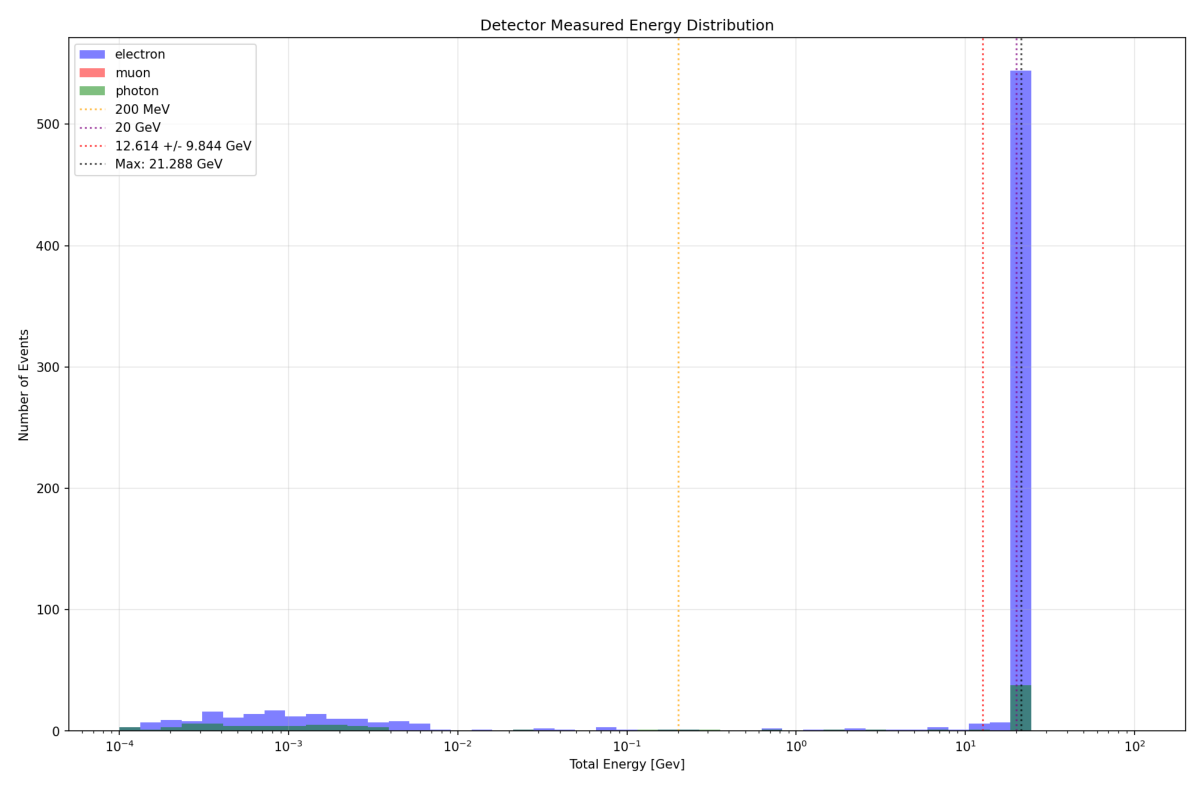

In [202]:
# Final Energy Distribution Plot: (taken from "Results/Detector Energy Distribution: {'ee'} (final).png")

img = mpimg.imread("Results/Detector Energy Distribution: {'ee'} (final).png")
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis('off')

# Understanding:

 To get a better picture of what is going on, I'd like to look into the energy deposited per layer and mess around with the layer thicknesses to better fit the radiation lengths for the electrons and photons in the calorimeter. Also, much to my dismay, I'd like to look into replacing the hadronic calorimeter with a larger EM calorimeter. See, originally, I wanted to properly simulate ppbar decay channels with a multitude of decay products, with a list of hadrons and leptons. Unfortunately, using Pythia8 to generate a custom HEPmc file was a bit of an ambitious task, so retiring the hadronic calorimeter in favor of getting better energy detection looks to be the best path to take. In general I think this would improve the sensitivity, switching from the iron material to more lead and the scintillators to more liquid argon will hopefully record more energy deposits.

 Firstly, looking at the energy deposits per layer:

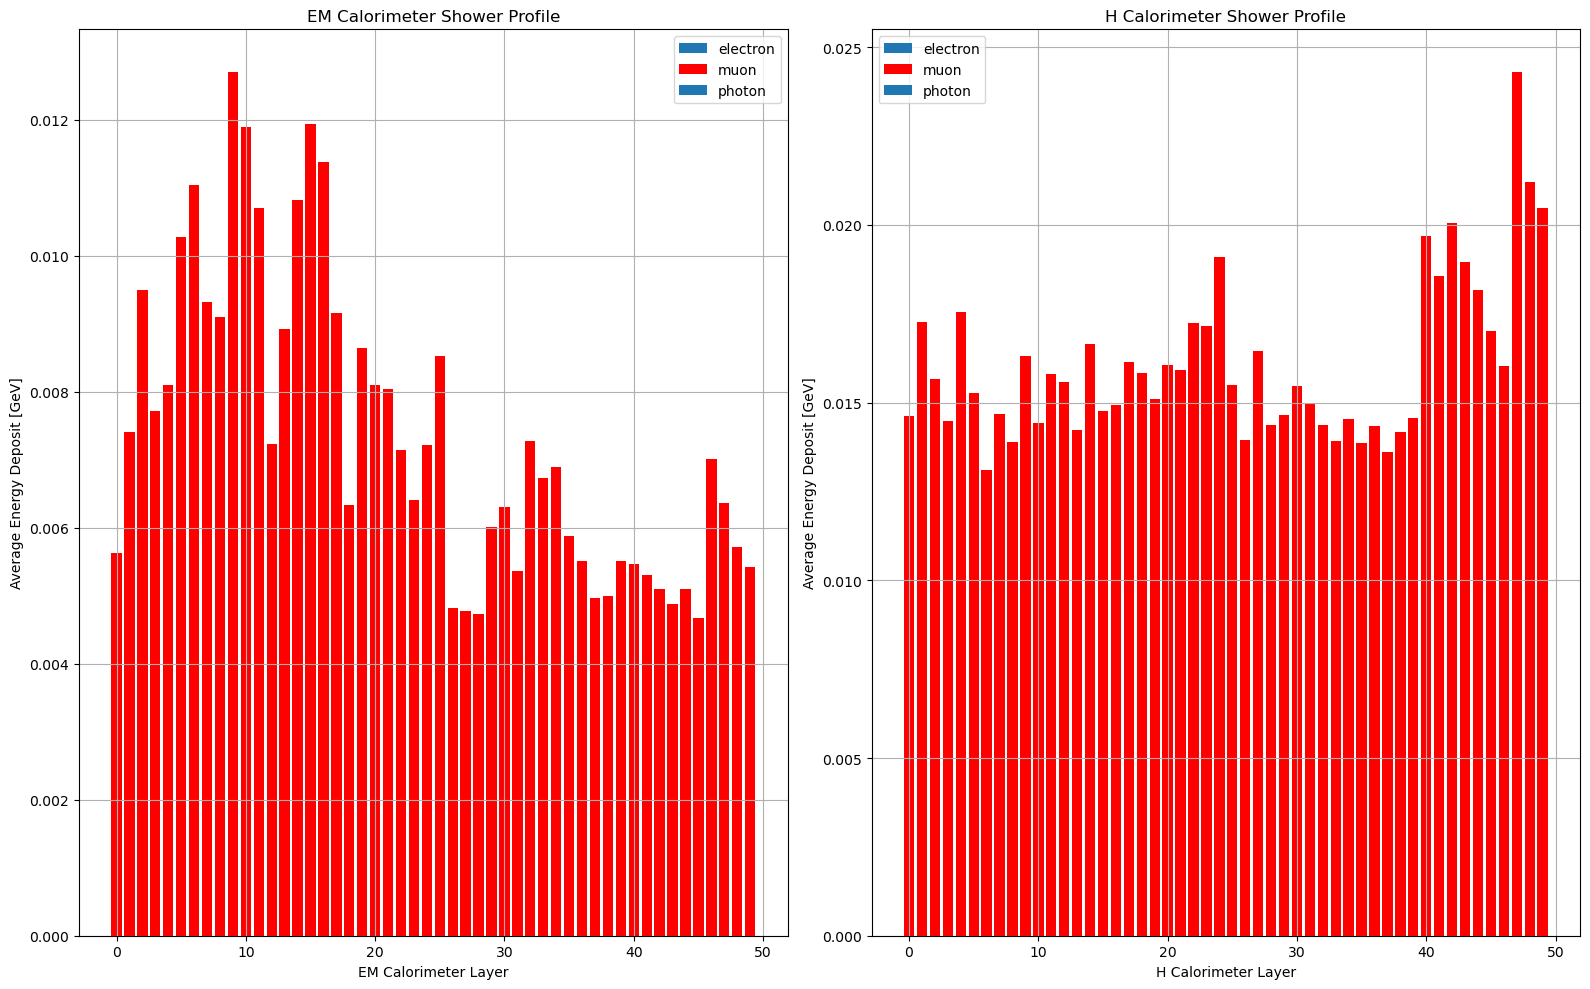

In [203]:
# Plotting the shower profiles for each particle type in the EM and H calorimeters

# Here we map the true particle types from results_df to the EM and H calorimeter Dataframes for plotting
event_to_type = results_df.set_index('EventID')['TrueType'].to_dict() # Labels use true particle types to avoid bias from misclassification (focus of this plot was the detected energy)
em_pd['TrueType'] = em_pd['EventID'].map(event_to_type)
h_pd['TrueType'] = h_pd['EventID'].map(event_to_type)

colors = {'electron': 'blue', 'muon': 'red', 'photon': 'green'}

plt.figure(figsize=(16,10))
plt.subplot(1,2,1)
for ptype, color in colors.items():
    subset = em_pd[em_pd['TrueType'] == ptype]
    profile = subset.groupby('LayerID')['Energy'].mean()
    plt.bar(profile.index, profile.values, color=color, label=ptype)

plt.xlabel('EM Calorimeter Layer')
plt.ylabel('Average Energy Deposit [GeV]')
plt.title('EM Calorimeter Shower Profile')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
for ptype, color in colors.items():
    subset = h_pd[h_pd['TrueType'] == ptype]
    profile = subset.groupby('LayerID')['Energy'].mean()
    plt.bar(profile.index, profile.values, color=color, label=ptype)

plt.xlabel('H Calorimeter Layer')
plt.ylabel('Average Energy Deposit [GeV]')
plt.title('H Calorimeter Shower Profile')
plt.legend()
plt.grid()

plt.tight_layout()
#plt.savefig(f'Results/Shower Profiles: {dataset} (final).png', dpi=150, bbox_inches='tight')
plt.show()

Looking at the results of the EM Calorimeter, we can see some surprising results. For the (ee) case (plots saved in the Results folder), we see all the energy deposited in the first layer; this makes sense for the electrons which shower immediately and with a shorter shower depth. For the photons, I'd expect to see more energy in the deeper layers since they typically have larger shower depths, which is seen in the (mumu) plot. What we see after is little to no energy detections with the other layers, very different to the (mumu) dataset. For the hadronic calorimeter, we see lots of activity in the (mumu) dataset, although the scale for energy deposited is slightly misleading; it is a stark contrast to the level of energy recorded compared to the (ee) dataset.

 This makes me reconsider fully replacing the hadronic calorimeter in favor of more EM layers since most of the energy is deposited in the first layer. Instead, I'll be modifying the ratio of the lAr to Pb thickness. These will be tracked in the plots with the filenames being denoted by (Pb thickness, lAr thickness) * cm. The original settings were: (5,3). The first example I'll use is a Pb thickness of half a radiation length (0.3 Pb, 0.3 lAr), since the radiation length of Pb ($\chi_0$ = 0.56 cm) is set as the length in which an electron will lose (1-1/e = 63%) of its energy. Did the same with the Fe ($\chi_0$ =  1.76 cm), going from (12,3) to (0.9, 0.9). Since this would decrease the size of the calorimeter greatly, I increased the number of layers from 20 (Em), 25(H) to 50 for both. For the (ee) dataset, this increased the amount of particles in the runs, so the set/cut was increased from 50mm to 100mm (lowered particle counts from ~100k to ~60k, still took around 20-30 mins). 

 After messing around with the calorimeter layers, we see a wider distribution in the energy deposits. Where as initially we only almost all the deposits in the first layer, decreasing the thickness of the layers to within a radiation length allows for better distribution of the shower profiles. Now we are able to actively detect more energy from each event, improving the range of our detector and its energy resolution.

(np.float64(-0.5), np.float64(2382.5), np.float64(1483.5), np.float64(-0.5))

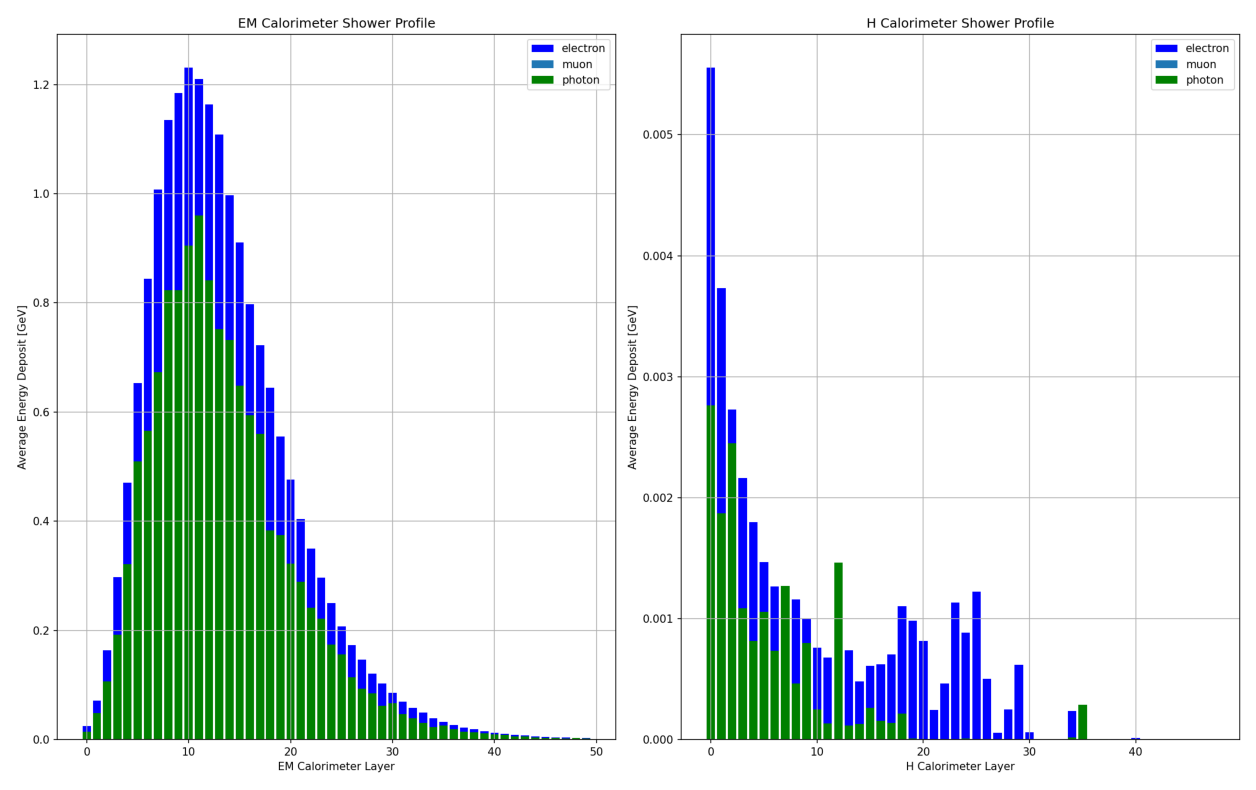

In [204]:
# Final Shower Profiles Plot: (taken from "Results/Shower Profiles: {'ee'} (final).png")

img = mpimg.imread("Results/Shower Profiles: {'ee'} (final).png")
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis('off')